In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from keras.applications.densenet import DenseNet169, DenseNet121
from keras.applications.mobilenet import MobileNet
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import classification_report
import lightgbm as lgb
import seaborn as sns

In [3]:
SIZE = 224
images = []
images_labels = [] 

In [5]:
ext = ['png', 'jpg', 'jpeg'] 

for directory_path in glob.glob("C:/Users/Acer/Desktop/PNEUMONIA_CLASS/*"):
    splited = directory_path.split("/")
    label = splited[-1]
    print(label)
    for e in ext:
      for img_path in glob.glob(os.path.join(directory_path, "*." + e)):
           print(img_path)
           img = cv2.imread(img_path, cv2.IMREAD_COLOR)       
           img = cv2.resize(img, (SIZE, SIZE))
           images.append(img)
           images_labels.append(label)

PNEUMONIA_CLASS\BACTERIAL_CLASS
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person135_virus_270.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person137_virus_281.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person139_virus_283.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person13_bacteria_49.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person140_virus_284.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person140_virus_285.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person141_virus_287.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person143_virus_289.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person145_virus_294.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person145_virus_295.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person146_virus_296.jpeg
C:/Users/Acer/Desktop/PNEUMONIA_CLASS\BACTERIAL_CLASS\person147_virus_297.jpeg
C:/Users/Acer/Deskt

In [4]:
images = np.array(images)
images_labels = np.array(images_labels)
     

In [5]:
images.shape

(5715, 224, 224, 3)

In [6]:
np.unique(images_labels)
     

array(['PNEUMONIA_CLASS\\BACTERIAL_CLASS',
       'PNEUMONIA_CLASS\\NORMAL_CLASS', 'PNEUMONIA_CLASS\\VIRAL_CLASS'],
      dtype='<U31')

In [7]:
le = preprocessing.LabelEncoder()
le.fit(images_labels)
labels_encoded = le.transform(images_labels)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(images, labels_encoded, test_size=0.2, random_state=0)
     

In [9]:
dense_model = DenseNet169(include_top=False, input_shape=(SIZE, SIZE, 3), pooling='avg')

In [10]:
dense_features = dense_model.predict(x_train)

In [11]:
features = dense_features.reshape(dense_features.shape[0], -1)
    

In [12]:
features.shape

(4572, 1664)

In [13]:
model_mobile = MobileNet(weights='imagenet',include_top=False, input_shape=(SIZE, SIZE, 3), pooling='avg')

In [14]:
mobile_features = model_mobile.predict(x_train)
     

In [15]:
features_2 = mobile_features.reshape(mobile_features.shape[0], -1)

In [16]:
features_2.shape

(4572, 1024)

In [17]:
combined_features = np.hstack((dense_features, mobile_features))
     

In [18]:
params = {'learning_rate':0.24, 'n_iterations': 250, 'max_depth': 7, 'num_leaves': 105, 'n_estimators': 300, 'min_child_samples': 40}

In [19]:
lgb_classifier = lgb.LGBMClassifier(**params)

In [20]:
lgb_classifier.fit(combined_features, y_train)

[LightGBM] [Warning] Unknown parameter: n_iterations


LGBMClassifier(learning_rate=0.24, max_depth=7, min_child_samples=40,
               n_estimators=300, n_iterations=250, num_leaves=105)

In [21]:
X_test_dense_features = dense_model.predict(x_test)
X_test_dense_features = X_test_dense_features.reshape(X_test_dense_features.shape[0], -1)

In [22]:
X_test_mobile_features = model_mobile.predict(x_test)
X_test_mobile_features = X_test_mobile_features.reshape(X_test_mobile_features.shape[0], -1)
     

In [23]:
X_test_mobile_features = model_mobile.predict(x_test)
X_test_mobile_features = X_test_mobile_features.reshape(X_test_mobile_features.shape[0], -1)
     

In [24]:
combined_test_features = np.hstack((X_test_dense_features, X_test_mobile_features))

In [25]:
prediction = lgb_classifier.predict(combined_test_features)

     

In [26]:
accuracy = accuracy_score(y_test, prediction)
accuracy

0.9755030621172354

In [27]:
cm = confusion_matrix(y_test, prediction)

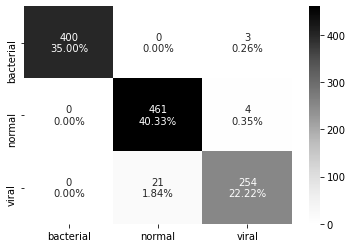

In [29]:
categories = ['bacterial','normal','viral']
counts = ['{0:0.0f}'.format(value) for value in
          cm.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in
                      cm.flatten()/np.sum(cm)]
labels = [f'{v1}\n{v2}' for v1, v2 in
          zip(counts, group_percentages)]
labels = np.asarray(labels).reshape(3, 3)


sns_plot = sns.heatmap(cm, annot=labels, fmt='', cmap='Greys',xticklabels=categories, yticklabels=categories)

In [30]:
def confusion_metrics(cm, class_name):
  report = classification_report(y_test, prediction, target_names=categories, output_dict=True)


  if class_name == 'bacterial':
      sensitivity = cm[0,0]/sum(cm[0,:])
      specificity = (cm[1,1]+cm[2,2])/(cm[1,0]+cm[2,0]+cm[1,1]+cm[2,2])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']

  elif class_name == 'normal':
      sensitivity = cm[2,2]/sum(cm[2,:])
      specificity = (cm[0,0]+cm[1,1])/(cm[0,2]+cm[1,2]+cm[0,0]+cm[1,1])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']
  elif class_name == 'viral':
      sensitivity = cm[2,2]/sum(cm[2,:])
      specificity = (cm[0,0]+cm[1,1])/(cm[0,2]+cm[1,2]+cm[0,0]+cm[1,1])
      precision = report[class_name]['precision']
      f1 = report[class_name]['f1-score']


  result = {'Sensitivity': sensitivity*100, 'Specificity': specificity *
              100, 'Precision': precision*100, 'F1-Score': f1*100}
  return result
     


In [31]:
performance = pd.DataFrame(
    columns=['Class', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'Accuracy'])
performance

,Class,Sensitivity,Specificity,Precision,F1-Score,Accuracy


In [32]:
for c in categories:
  data = {**{'Class': f'{c}'}, **confusion_metrics(cm, c), **{'Accuracy': accuracy*100 }}
  performance = performance.append(data, ignore_index=True)

In [33]:
for c in categories:
  data = {**{'Class': f'{c}'}, **confusion_metrics(cm, c), **{'Accuracy': accuracy*100 }}
  performance = performance.append(data, ignore_index=True)performance

,Class,Sensitivity,Specificity,Precision,F1-Score,Accuracy
0,bacterial,99.255583,100.000000,100.000000,99.626401,97.550306
1,normal,92.363636,99.193548,95.643154,97.360084,97.550306
2,viral,92.363636,99.193548,97.318008,94.776119,97.550306


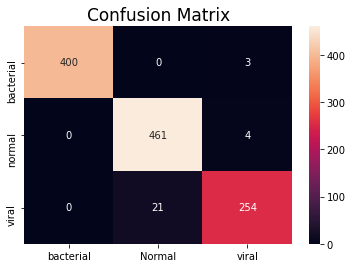

In [38]:
from sklearn.metrics import confusion_matrix
#compute the confusion matrix.
cm = confusion_matrix(y_test,prediction)
 
#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['bacterial','Normal','viral'],
            yticklabels=['bacterial','normal','viral'])
#plt.ylabel('Prediction',fontsize=13)
#plt.xlabel('y_test',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()